### 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/ML Projects/Mental Health Score Predictor/dataset_csv.csv")

In [3]:
# Looking for numbers of rows and columns

df.shape

(5000, 13)

In [4]:
# Look at first 5 rows

df.head(5)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
# check null vlaues
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [6]:
# check duplicate values
df.duplicated().sum()

np.int64(2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of the target (Mental_Health_Score)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

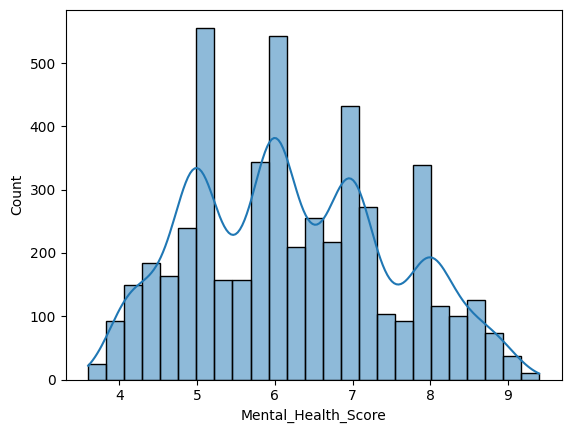

In [8]:
sns.histplot(df['Mental_Health_Score'], kde=True)

### 3.2 Correlation Heatmap

<Axes: >

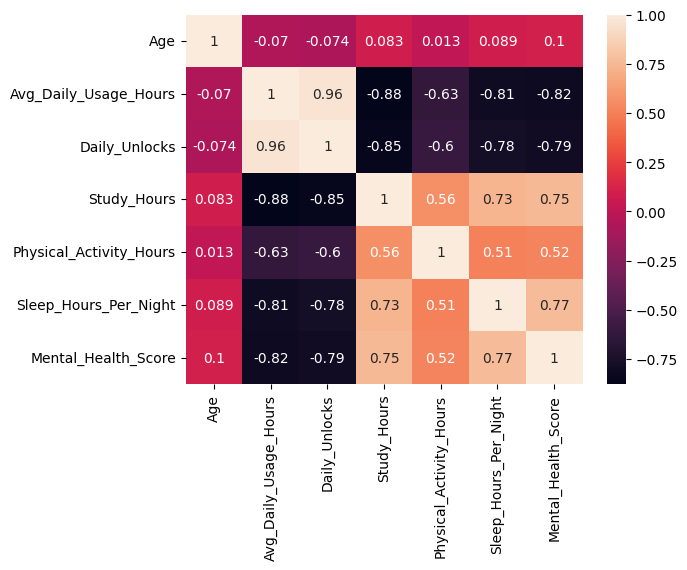

In [9]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### 3.3 Stress Level vs Mental Health Score

In [10]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

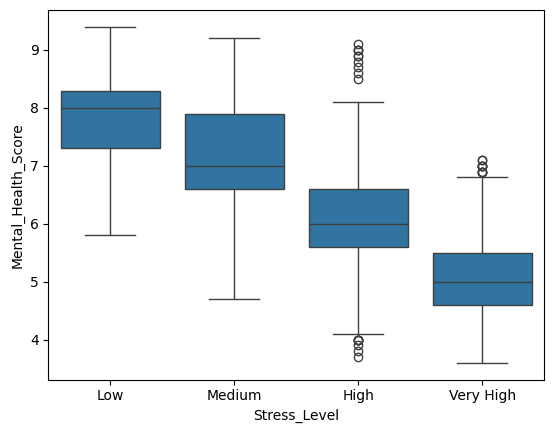

In [11]:
order = ['Low', 'Medium', 'High','Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order)

<Axes: xlabel='Stress_Level', ylabel='count'>

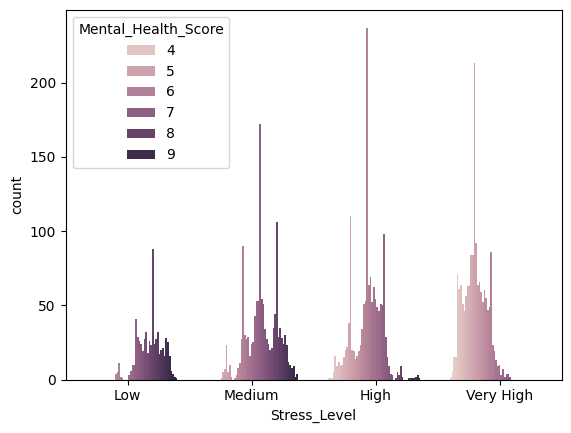

In [12]:
sns.countplot(x='Stress_Level', hue='Mental_Health_Score', data=df, order=order)

### 3.3 Daily Usage Hours vs Mental Health Score

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

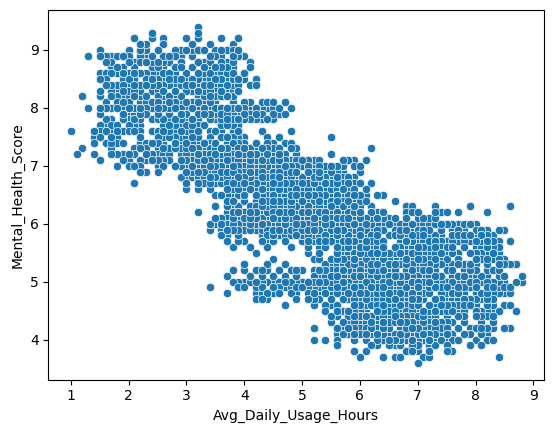

In [13]:
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)

### 3.4 Study Hours vs Mental Health Score

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

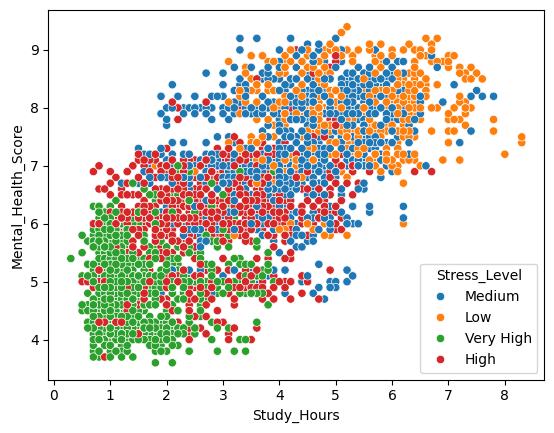

In [14]:
sns.scatterplot(x='Study_Hours', y='Mental_Health_Score', data=df, hue='Stress_Level')

### 3.5 Sleep Hours vs Mental Health Score

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

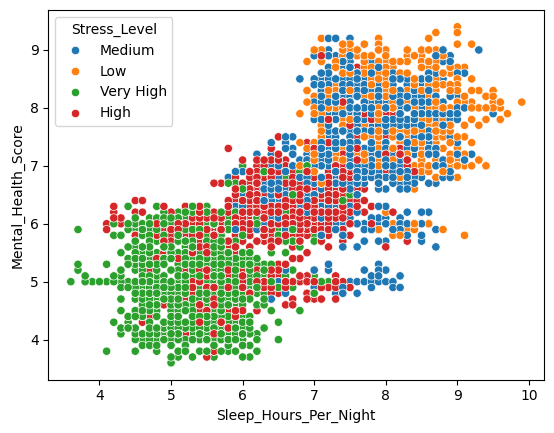

In [15]:
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df, hue='Stress_Level')

## 4. Checking Outliers

In [16]:
num_features = df.select_dtypes(include='number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
outliers.sum()


,0
Age,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,2
Physical_Activity_Hours,22
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [17]:
outliers2 = df[
    (df["Physical_Activity_Hours"] < lower_bound["Physical_Activity_Hours"]) |
    (df["Physical_Activity_Hours"] > upper_bound["Physical_Activity_Hours"])
]

outliers2

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
934,22,Female,Other,Undergraduate,TikTok,Entertainment,2.3,93,5.8,3.6,8.0,Low,8.5
1784,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,2.9,132,4.2,3.6,7.0,Medium,7.0
2082,21,Male,India,Undergraduate,Instagram,Entertainment,3.3,136,5.9,3.6,6.9,Medium,7.2
2277,20,Male,Other,Undergraduate,Facebook,Networking,6.8,222,2.6,-0.1,4.7,Very High,4.6
2512,24,Female,Other,Graduate,Instagram,Entertainment,2.1,103,7.2,3.6,8.1,Low,8.7
2549,22,Male,Afghanistan,Undergraduate,LinkedIn,Education,2.6,132,4.2,3.6,6.8,Medium,7.1
2923,23,Female,USA,Graduate,Snapchat,Entertainment,7.9,223,1.1,-0.1,5.8,Very High,5.2
3051,22,Male,Japan,Undergraduate,Twitter,News,4.6,149,3.1,3.7,7.4,Medium,8.0
3056,19,Male,Other,Undergraduate,LinkedIn,Education,7.8,252,1.6,-0.3,5.7,Very High,4.3
3422,24,Male,Other,Graduate,Twitter,News,8.2,245,0.7,-0.1,5.8,Very High,4.4


In [18]:
df = df[df["Physical_Activity_Hours"] >= 0]

## 5. Data Cleaning

In [19]:
# 1. Drop Duplicates rows
df = df.drop_duplicates()

In [20]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4988.000000,4988.000000,4988.000000,4988.000000,4988.000000,4988.000000,4988.000000
mean,20.822374,5.074539,171.347835,3.010706,1.754671,6.636949,6.233841
std,1.737116,1.652778,42.827688,1.637380,0.663322,1.221215,1.278005
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## 6. Skewness

In [21]:
num_features.skew()

,0
Age,0.155325
Avg_Daily_Usage_Hours,0.005606
Daily_Unlocks,0.002351
Study_Hours,0.435819
Physical_Activity_Hours,0.039971
Sleep_Hours_Per_Night,0.124050
Mental_Health_Score,0.206567


## 7. Feature Enginnering

In [22]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [23]:
def categorize_country(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [24]:
df["grouped_country"] = df['Country'].apply(categorize_country)

In [25]:
df['grouped_country'].value_counts()

,count
grouped_country,
Other,3223
India,388
USA,353
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


## 8. Encoding Strategy
Before we jump into code, let's decide how each categorical column should be encoded — this decision matters more than the code itself.


*   **`Stress_Level` → Ordinal Encoding.** Its categories have a real, meaningful order: Low < Medium < High < Very High. We already saw in EDA (section 4.3) that the score drops step by step as stress increases — encoding it as 0, 1, 2, 3 preserves that order for the model.
*   **Gender, Academic_Level, Most_Used_Platform, Purpose_Of_Use, Country_Grouped → One-Hot Encoding.** These categories have **no natural order** — "Instagram" isn't "greater than" "LinkedIn". One-hot encoding creates a separate 0/1 column per category so the model doesn't accidentally assume a false ranking.

We'll implement both of these inside a single ColumnTransformer in the next step, rather than doing it manually column by column — that keeps preprocessing consistent and reusable.


## 9. Train Test Split

In [26]:
from sklearn.model_selection import train_test_split

skwewd_cols =        ["Study_Hours"]
other_numeric_cols = ["Age","Avg_Daily_Usage_Hours","Daily_Unlocks","Physical_Activity_Hours","Sleep_Hours_Per_Night"]
ordinal_cols =       ["Stress_Level"]
categorical_cols =   ["Gender","Academic_Level","Most_Used_Platform","Purpose_Of_Use","grouped_country"]

feature_cols = skwewd_cols + other_numeric_cols + ordinal_cols + categorical_cols

X = df[feature_cols]
y = df["Mental_Health_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 10. Preprocessing using ColumnTransformer
Our columns need **different treatment**:

*  `Study_Hours` (the skewed one) → impute → `log1p` transform → scale
*  The other numeric columns → impute → scale (no skew to fix)
*  `Stress_Level` → impute → `OrdinalEncoder` with an **explicit order**
*  The nominal columns → impute → `OneHotEncoder`

We include a `SimpleImputer` in every branch even though this dataset has zero missing values right now — it's a safety net. Real-world data (and our future API's incoming requests) won't always be this clean, and a pipeline that assumes "no missing values ever" is a pipeline that breaks in production.

`ColumnTransformer` glues all of this into one object that applies the right transformation to the right column type in a single `.fit()` / `.transform()` call — no manual column-by-column juggling.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer ,StandardScaler, OneHotEncoder, OrdinalEncoder

# Skewed Features
skew_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

# Numerical Features
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='mean')),
    ('scale', StandardScaler())
])

# Ordinal Features
ordinal_pipeline = Pipeline(steps=[
   ( 'impute', SimpleImputer(strategy='most_frequent')),
   ( 'ordinal', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

# Nominal Features
nominal_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('skew', skew_pipeline, skwewd_cols),
    ('numeric', numeric_pipeline, other_numeric_cols),
    ('ordinal', ordinal_pipeline, ordinal_cols),
    ('nominal', nominal_pipeline, categorical_cols)
])


In [28]:
preprocessor

ColumnTransformer(transformers=[('skew',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['Study_Hours']),
                                ('numeric',
                                 Pipeline(steps=[('impute', SimpleImputer()),
                                                 ('scale', StandardScaler())]),
                                 ['Age', 'Avg_Daily_Usage_Hours',
                                  'Daily_Unlocks', 'Physical_Activ...
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['Stress_Level']),
                                ('nominal',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Gender', 'Academic_Level',
                                  'Most_Used_Platform', 'Purpose_Of_Use',
                                  'grouped_country'])])

## 11. Build a Pipeline
**Why Pipeline matters:** a `Pipeline` chains preprocessing and the model into a single object. Calling `.fit()` once does both steps in the correct order, and calling `.predict()` on brand-new raw data automatically applies the exact same preprocessing that was used during training — no risk of forgetting a step or applying it inconsistently.

**Why companies prefer this:** when this model gets deployed (which we're doing in Part 2 with FastAPI), the API doesn't need to know anything about scaling, encoding, or log transforms — it just loads one saved pipeline object and calls `.predict()` on raw input. That's a huge reduction in what can go wrong in production.

We'll build two pipelines below — one per model — so we can fairly compare them.

## 12. Model Building

### 12.1 — Baseline: Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict((X_train))

lr_r2_testing = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae_score = mean_absolute_error(y_test, lr_preds)
lr_mse_score = mean_squared_error(y_test, lr_preds)

print(f"R2 Score (Testing): {lr_r2_testing}")
print(f"R2 Score (Training): {lr_r2_training}")
print(f"MAE Score: {lr_mae_score}")
print(f"MSE Score: {lr_mse_score}")

R2 Score (Testing): 0.7407562540314494
R2 Score (Training): 0.7233143016461888
MAE Score: 0.5209052730542254
MSE Score: 0.4370382857692943


### 12.2 — Random Forest (default settings)

In [32]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor())
])
rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)

rf_r2_testing = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_train)
rf_mae_score = mean_absolute_error(y_test, rf_preds)
rf_mse_score = mean_squared_error(y_test, rf_preds)

print(f"R2 Score (Testing): {rf_r2_testing}")
print(f"R2 Score (Training): {rf_r2_training}")
print(f"MAE Score: {rf_mae_score}")


R2 Score (Testing): 0.8860199723897765
R2 Score (Training): 0.9810382318228582
MAE Score: 0.32767139994274275


### 12.3 — Hyperparameter Tuning the Random Forest

In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'regressor__n_estimators'       : [100,200,300],
    'regressor__max_depth'         : [5,10,15],
    'regressor__min_samples_split' : [2,5,10],
    'regressor__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('skew',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('numeric',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer()),
                                                                                               ('scale',
                                                                                                StandardScaler()...
                                                                               ['Gender',
                                                                                'Academic_Level',
                                                                                'Most_Used_Platform',
                                                                                'Purpose_Of_Use',
                                                                                'grouped_country'])])),
                                             ('regressor',
                                              RandomForestRegressor())]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [5, 10, 15],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300]},
                   random_state=42, scoring='r2')

In [34]:
random_search.best_params_

{'regressor__n_estimators': 300,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_depth': 15}

In [35]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds = rf_best_pipeline.predict(X_test)
rf_best_preds_train = rf_best_pipeline.predict(X_train)

rf_best_r2_testing = r2_score(y_test, rf_best_preds)
rf_best_r2_training = r2_score(y_train, rf_best_preds_train)
rf_best_mae_score = mean_absolute_error(y_test, rf_best_preds)
rf_best_mse_score = mean_squared_error(y_test, rf_best_preds)
print(f"R2 Score (Testing): {rf_best_r2_testing}")
print(f"R2 Score (Training): {rf_best_r2_training}")
print(f"MAE Score: {rf_best_mae_score}")

R2 Score (Testing): 0.8732332426324141
R2 Score (Training): 0.9554960753622764
MAE Score: 0.3507407353232761


## 13. Model Evaluation
Metrics, explained simply:


*   **R² Score** — how much of the variation in mental health scores our model explains, from 0 (useless) to 1 (perfect). 0.85 means the model explains 85% of the pattern.
*   **MAE (Mean Absolute Error)** — on average, how far off our prediction is, in the original units (score points). Easy to explain to a non-technical person.
*   **RMSE (Root Mean Squared Error)** — similar to MAE, but penalizes big mistakes more heavily. Useful for spotting whether a model makes a few very wrong predictions.

Cross-validation R² (from tuning, above) tells us how good the model is across many different train/validation splits — the real, honest test is still the untouched test set below.

In [36]:
# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae_score, rf_mae_score, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.740756     0.723314  0.520905  0.661089
1  Random Forest (default)  0.886020     0.981038  0.327671  0.438349
2    Random Forest (tuned)  0.873233     0.955496  0.350741  0.462283


### 14. Save the Model

In [37]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']